In [9]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

print("✅ Libraries loaded successfully")

✅ Libraries loaded successfully


In [10]:
# Ensure all output folders exist
import os

os.makedirs('../results/cluster_plots', exist_ok=True)
os.makedirs('../results/pca_outputs', exist_ok=True)
os.makedirs('../results/metrics', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

print("✅ All output directories confirmed")

✅ All output directories confirmed


In [11]:

df_2009 = pd.read_excel('../data/raw/online_retail_II.xlsx', sheet_name='Year 2009-2010')
df_2010 = pd.read_excel('../data/raw/online_retail_II.xlsx', sheet_name='Year 2010-2011')

# Combine both years
df = pd.concat([df_2009, df_2010], ignore_index=True)

print(f"Shape: {df.shape}")
print(f"Total records: {len(df):,}")
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (1067371, 8)
Total records: 1,067,371

Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

First 5 rows:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom


In [12]:

print("=" * 50)
print("DATASET INFO")
print("=" * 50)
df.info()

print("\n" + "=" * 50)
print("STATISTICAL SUMMARY")
print("=" * 50)
df.describe()

DATASET INFO
<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 65.1+ MB

STATISTICAL SUMMARY


,Quantity,InvoiceDate,Price,Customer ID
count,1067371.00,1067371,1067371.00,824364.00
mean,9.94,2011-01-02 21:13:55.394029,4.65,15324.64
min,-80995.00,2009-12-01 07:45:00,-53594.36,12346.00
25%,1.00,2010-07-09 09:46:00,1.25,13975.00
50%,3.00,2010-12-07 15:28:00,2.10,15255.00
75%,10.00,2011-07-22 10:23:00,4.15,16797.00
max,80995.00,2011-12-09 12:50:00,38970.00,18287.00
std,172.71,NaN,123.55,1697.46


MISSING VALUES REPORT
             Missing Count  Missing %
Customer ID         243007      22.77
Description           4382       0.41


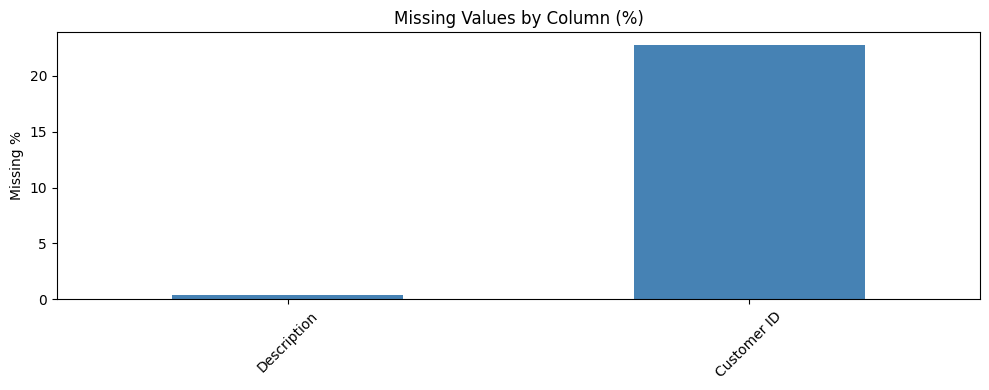

✅ Plot saved


In [13]:
# Missing value analysis
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

print("MISSING VALUES REPORT")
print(missing_df[missing_df['Missing Count'] > 0])

# Visualize
plt.figure(figsize=(10, 4))
missing_pct[missing_pct > 0].plot(kind='bar', color='steelblue')
plt.title('Missing Values by Column (%)')
plt.ylabel('Missing %')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../results/cluster_plots/missing_values.png', dpi=150)
plt.show()
print("✅ Plot saved")

In [14]:
# Handle missing values

print(f"Records before cleaning: {len(df):,}")

# 1. Drop rows with no CustomerID — we can't do customer segmentation without it
df.dropna(subset=['Customer ID'], inplace=True)
print(f"After dropping missing CustomerID: {len(df):,}")

# 2. Drop rows with missing Description (very few, negligible)
df.dropna(subset=['Description'], inplace=True)
print(f"After dropping missing Description: {len(df):,}")

# Confirm no more missing values
print("\nMissing values remaining:")
print(df.isnull().sum())

Records before cleaning: 1,067,371
After dropping missing CustomerID: 824,364
After dropping missing Description: 824,364

Missing values remaining:
Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64


In [15]:
# Remove cancellations and invalid records

# Cancellations have InvoiceNo starting with 'C'
df['is_cancelled'] = df['Invoice'].astype(str).str.startswith('C')
cancelled_count = df['is_cancelled'].sum()
print(f"Cancelled transactions: {cancelled_count:,}")

# Keep a record of cancellation rate per customer (useful feature later)
cancellation_rate = df.groupby('Customer ID')['is_cancelled'].mean().reset_index()
cancellation_rate.columns = ['Customer ID', 'cancellation_rate']

# Remove cancelled orders from main df
df = df[~df['is_cancelled']].copy()
print(f"After removing cancellations: {len(df):,}")

# Remove rows where Quantity <= 0
df = df[df['Quantity'] > 0]
print(f"After removing non-positive quantities: {len(df):,}")

# Remove rows where Price <= 0
df = df[df['Price'] > 0]
print(f"After removing non-positive prices: {len(df):,}")

df.drop(columns=['is_cancelled'], inplace=True)

Cancelled transactions: 18,744
After removing cancellations: 805,620
After removing non-positive quantities: 805,620
After removing non-positive prices: 805,549


In [16]:
# Create core features needed for segmentation

# Total spend per transaction
df['TotalSpend'] = df['Quantity'] * df['Price']

# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Reference date for Recency calculation (day after last transaction)
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Reference date for Recency: {reference_date.date()}")

print("\nSample with TotalSpend:")
df[['Customer ID', 'Invoice', 'Quantity', 'Price', 'TotalSpend', 'InvoiceDate']].head()

Reference date for Recency: 2011-12-10

Sample with TotalSpend:


,Customer ID,Invoice,Quantity,Price,TotalSpend,InvoiceDate
0,13085.00,489434,12,6.95,83.40,2009-12-01 07:45:00
1,13085.00,489434,12,6.75,81.00,2009-12-01 07:45:00
2,13085.00,489434,12,6.75,81.00,2009-12-01 07:45:00
3,13085.00,489434,48,2.10,100.80,2009-12-01 07:45:00
4,13085.00,489434,24,1.25,30.00,2009-12-01 07:45:00


In [17]:
# Build RFM + extended features at customer level

customer_df = df.groupby('Customer ID').agg(
    # RFM core
    Recency        = ('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency      = ('Invoice',     'nunique'),
    Monetary       = ('TotalSpend',  'sum'),

    # Behavioral features
    AvgOrderValue  = ('TotalSpend',  'mean'),
    TotalItems     = ('Quantity',    'sum'),
    AvgItemsPerOrder = ('Quantity',  'mean'),
    UniqueProducts = ('StockCode',   'nunique'),
    NumCountries   = ('Country',     'nunique'),
    FirstPurchase  = ('InvoiceDate', 'min'),
    LastPurchase   = ('InvoiceDate', 'max'),
).reset_index()

# Derived features
customer_df['CustomerAge'] = (reference_date - customer_df['FirstPurchase']).dt.days
customer_df['AvgDaysBetweenOrders'] = customer_df['CustomerAge'] / customer_df['Frequency']
customer_df['SpendPerItem'] = customer_df['Monetary'] / customer_df['TotalItems']

# Merge cancellation rate
customer_df = customer_df.merge(cancellation_rate, on='Customer ID', how='left')
customer_df['cancellation_rate'] = customer_df['cancellation_rate'].fillna(0)

# Drop date columns (not needed for clustering)
customer_df.drop(columns=['FirstPurchase', 'LastPurchase'], inplace=True)

print(f"Customer-level dataset shape: {customer_df.shape}")
print(f"Total unique customers: {len(customer_df):,}")
print(f"\nFeatures created: {customer_df.columns.tolist()}")
customer_df.head()

Customer-level dataset shape: (5878, 13)
Total unique customers: 5,878

Features created: ['Customer ID', 'Recency', 'Frequency', 'Monetary', 'AvgOrderValue', 'TotalItems', 'AvgItemsPerOrder', 'UniqueProducts', 'NumCountries', 'CustomerAge', 'AvgDaysBetweenOrders', 'SpendPerItem', 'cancellation_rate']


,Customer ID,Recency,Frequency,Monetary,AvgOrderValue,TotalItems,AvgItemsPerOrder,UniqueProducts,NumCountries,CustomerAge,AvgDaysBetweenOrders,SpendPerItem,cancellation_rate
0,12346.00,326,12,77556.46,2281.07,74285,2184.85,27,1,726,60.50,1.04,0.29
1,12347.00,2,8,5633.32,22.27,3286,12.99,126,1,404,50.50,1.71,0.00
2,12348.00,75,5,2019.40,39.60,2714,53.22,25,1,438,87.60,0.74,0.00
3,12349.00,19,4,4428.69,25.31,1624,9.28,138,1,589,147.25,2.73,0.03
4,12350.00,310,1,334.40,19.67,197,11.59,17,1,310,310.00,1.70,0.00


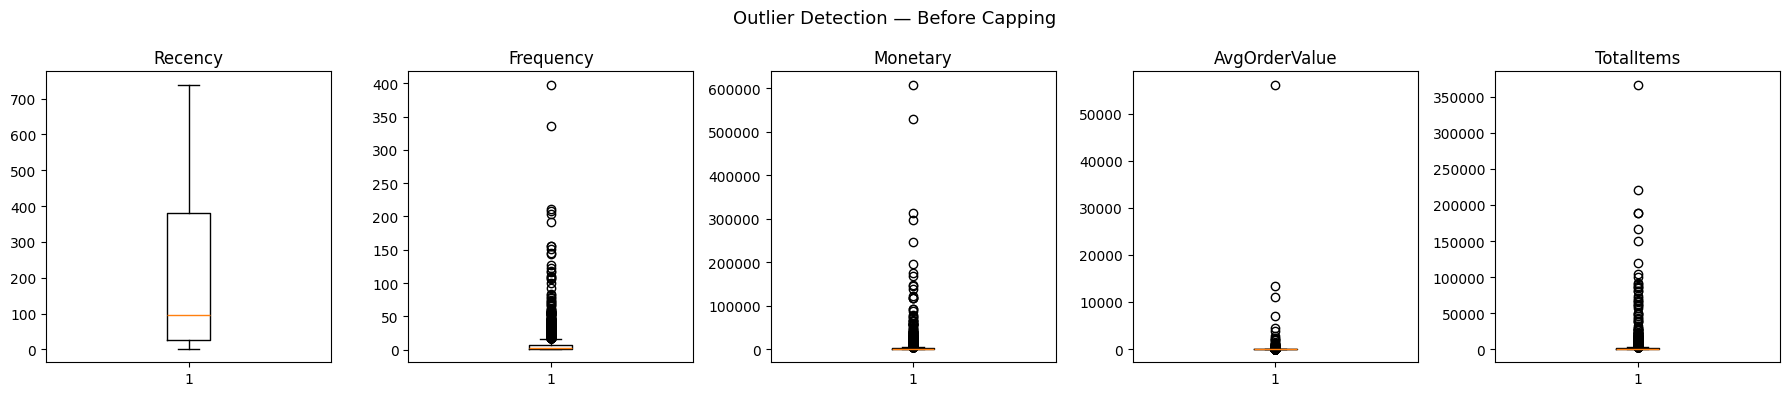

Recency: capped at 726.00
Frequency: capped at 46.00
Monetary: capped at 29730.42
AvgOrderValue: capped at 363.13
TotalItems: capped at 17491.68

✅ Outliers capped at 99th percentile


In [18]:
# Outlier detection and capping

features_to_check = ['Recency', 'Frequency', 'Monetary', 'AvgOrderValue', 'TotalItems']

fig, axes = plt.subplots(1, len(features_to_check), figsize=(18, 4))
for i, col in enumerate(features_to_check):
    axes[i].boxplot(customer_df[col].dropna())
    axes[i].set_title(col)
    axes[i].set_xlabel('')
plt.suptitle('Outlier Detection — Before Capping', fontsize=13)
plt.tight_layout()
plt.savefig('../results/cluster_plots/outliers_before.png', dpi=150)
plt.show()

# Cap outliers at 99th percentile (Winsorization)
for col in features_to_check:
    upper = customer_df[col].quantile(0.99)
    customer_df[col] = customer_df[col].clip(upper=upper)
    print(f"{col}: capped at {upper:.2f}")

print("\n✅ Outliers capped at 99th percentile")

In [19]:
# Save the processed customer-level dataset

customer_df.to_csv('../data/processed/customer_features.csv', index=False)

print("✅ Saved to: data/processed/customer_features.csv")
print(f"\nFinal dataset shape: {customer_df.shape}")
print(f"\nFeature list ({len(customer_df.columns)} columns):")
for i, col in enumerate(customer_df.columns, 1):
    print(f"  {i:2}. {col}")

✅ Saved to: data/processed/customer_features.csv

Final dataset shape: (5878, 13)

Feature list (13 columns):
   1. Customer ID
   2. Recency
   3. Frequency
   4. Monetary
   5. AvgOrderValue
   6. TotalItems
   7. AvgItemsPerOrder
   8. UniqueProducts
   9. NumCountries
  10. CustomerAge
  11. AvgDaysBetweenOrders
  12. SpendPerItem
  13. cancellation_rate


In [20]:
# Summary

print("=" * 55)
print("  PREPROCESSING COMPLETE — SUMMARY")
print("=" * 55)
print(f"  Raw transactions loaded    : {len(df_2009) + len(df_2010):>10,}")
print(f"  After removing no-CustomerID: {len(df):>10,}")
print(f"  Unique customers segmented : {len(customer_df):>10,}")
print(f"  Features engineered        : {len(customer_df.columns) - 1:>10}")
print(f"  RFM features               :          3")
print(f"  Behavioral features        :          9")
print(f"  Outlier method             :   Winsorize (99th pct)")
print(f"  Saved to                   : data/processed/")
print("=" * 55)
print("\n✅ Ready for EDA (Notebook 02)")

  PREPROCESSING COMPLETE — SUMMARY
  Raw transactions loaded    :  1,067,371
  After removing no-CustomerID:    805,549
  Unique customers segmented :      5,878
  Features engineered        :         12
  RFM features               :          3
  Behavioral features        :          9
  Outlier method             :   Winsorize (99th pct)
  Saved to                   : data/processed/

✅ Ready for EDA (Notebook 02)
